# Nepali → English Translation Fine-Tuning — Llama 3.2 3B v4
## Research-grade Kaggle / QLoRA pipeline

### Goal
Train a specialized Nepali → English translation adapter and compare it fairly against the untouched base model.

This notebook is designed around the goal:

> **Fine-tuned Llama 3.2 3B should outperform the base model across diverse Nepali→English translation scenarios, not only on one random BLEU score.**

### Data sources
- **Main organic corpus:** `iamTangsang/Nepali-to-English-Translation-Dataset`
- **FLORES-200 dev set** (`facebook/flores`, `npi_Deva-eng_Latn`) — small, high-quality, human-translated.
- **Your synthetic augmentation set:** `iwasbinod/nepali_translation_jsonl_format` — the templated
  Short/Simple, Complex/Compound, Idiomatic, News-domain, Technical/Scientific, Numbers/Dates/Proper-Noun,
  and Long-Paragraph examples you generated and pushed to the Hub.

### Why the synthetic set is handled specially
Synthetic, templated data is great for teaching the model consistent patterns (tense, ergative case,
idiom structure, number formatting), but if the *same* templated sentences also end up in the
test/validation split, BLEU/chrF++ improvements would be partly an illusion — the model would just be
recognizing patterns it memorized, not generalizing. So this notebook:
- Uses the synthetic set **only inside the training pool**.
- Builds the **diagnostic, validation, and final test sets exclusively from organic (main + FLORES) data**,
  so every reported improvement reflects real generalization.
- Still runs one extra **bonus, in-distribution check** on a small held-out synthetic slice (never trained
  on) at the end, so you can see how well the model learned your specific synthetic patterns too.
- Deduplicates globally across all three sources (exact nepali+english match, then one english per nepali),
  with organic data taking priority over synthetic on any collision, so nothing is double-counted or leaks
  between train and eval.

### Main improvements over the previous v3 notebook
- Third data source (your Hugging Face synthetic dataset) merged in with automatic schema detection
  (`input`/`output`, `source`/`target`, `Nepali`/`English`, or FLORES-style columns).
- Organic-only evaluation splits; synthetic data boosts training only.
- Bonus in-distribution synthetic-holdout evaluation, broken down by your original categories
  (Idiomatic, News-domain, etc.).
- Fixed a `QUICK_RUN` ordering bug where `RUN_BERTSCORE` was silently forced back to `True`.
- Stronger cleaning and exact deduplication (unchanged, still applied across all sources together).
- Separate **diagnostic pool**, **training**, **validation**, and **final test** data.
- Base-model failure analysis on a diagnostic pool, followed by hard-example oversampling.
- Category-aware evaluation: general, short, long, code-mixed, and numeric/proper-noun examples where available.
- Target-only loss using a custom collator, avoiding fragile response-template matching.
- Validation loss and checkpoint selection.
- Final evaluation with BLEU, chrF++, optional BERTScore


## 1. Install dependencies

In [1]:
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps peft accelerate bitsandbytes datasets huggingface_hub
!pip install -q sacrebleu pandas numpy scikit-learn
!pip install -q bert-score || true

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.9 MB/s eta

## 2. Configuration

In [2]:
import os, re, gc, json, math, random, inspect, warnings
import numpy as np
import pandas as pd
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE_MODEL = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"

# Organic (real, human-translated) sources — used for training AND evaluation.
MAIN_DATASET = "iamTangsang/Nepali-to-English-Translation-Dataset"
MAIN_SPLIT = "train"
USE_FLORES = True

# Your synthetic / templated augmentation set — used for TRAINING ONLY.
# Kept out of val/diagnostic/test so reported BLEU/chrF++ gains reflect real
# generalization rather than the model recognizing memorized templates.
SYNTHETIC_DATASET = "iwasbinod/nepali_translation_jsonl_format"
SYNTHETIC_SPLIT = "train"
USE_SYNTHETIC = True
# Small slice of the synthetic set held out (never trained on) purely for a
# bonus "how well did it learn my exact patterns" diagnostic at the end.
SYNTHETIC_HOLDOUT_SIZE = 300

MAX_WORKING_EXAMPLES = 100000
TRAIN_SIZE = 40000          # organic examples drawn into the training pool
VAL_SIZE = 2000
DIAGNOSTIC_SIZE = 1500
TEST_SIZE = 2000

ENABLE_HARD_MINING = True
HARD_EXAMPLE_OVERSAMPLE = 2

MAX_SEQ_LENGTH = 1536
NUM_EPOCHS = 2.0
PER_DEVICE_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 2e-5
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

MAX_NEW_TOKENS = 256

EVAL_BATCH_SIZE = 8
RUN_BERTSCORE = True  # Set False for a faster Kaggle run

# Optional smoke-test mode: set True to validate the full pipeline quickly.
# It is intentionally False for the full research run.
# NOTE: this must come AFTER the RUN_BERTSCORE default above, so QUICK_RUN can
# correctly force it back to False for a fast smoke test.
QUICK_RUN = True
if QUICK_RUN:
    TRAIN_SIZE = 2000
    VAL_SIZE = 200
    DIAGNOSTIC_SIZE = 200
    TEST_SIZE = 300
    SYNTHETIC_HOLDOUT_SIZE = 100
    NUM_EPOCHS = 1.0
    RUN_BERTSCORE = False

HF_USERNAME = "iwasbinod"
ADAPTER_NAME = "llama-3.2-3b-nepali-english-translation-with_syn_v4"

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: Tesla T4


## 3. Hugging Face login

In [3]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(hf_token)
print("Hugging Face login successful.")

Hugging Face login successful.


## 4. Load and standardize translation data

In [4]:
from datasets import load_dataset, concatenate_datasets

def standardize(example):
    """Map any of the supported schemas onto {nepali, english, src_category}.

    src_category preserves your original synthetic category (e.g. "Idiomatic",
    "News-domain") under its own column name so it never collides with the
    pipeline's own short/medium/long/code_mixed `category` column added later.
    """
    keys = set(example.keys())
    if {"input", "output"}.issubset(keys):
        return {
            "nepali": example["input"],
            "english": example["output"],
            "src_category": example.get("category", "") or "",
        }
    if {"source", "target"}.issubset(keys):
        return {"nepali": example["source"], "english": example["target"], "src_category": ""}
    if {"sentence_npi_Deva", "sentence_eng_Latn"}.issubset(keys):
        return {
            "nepali": example["sentence_npi_Deva"],
            "english": example["sentence_eng_Latn"],
            "src_category": "",
        }
    if {"Nepali", "English"}.issubset(keys):
        return {"nepali": example["Nepali"], "english": example["English"], "src_category": ""}
    text_cols = [k for k in example.keys() if isinstance(example[k], str)]
    if len(text_cols) >= 2:
        return {"nepali": example[text_cols[0]], "english": example[text_cols[1]], "src_category": ""}
    return {"nepali": "", "english": "", "src_category": ""}


def load_and_tag(name, split, source_tag, config_name=None):
    ds = load_dataset(name, config_name, split=split) if config_name else load_dataset(name, split=split)
    ds = ds.map(standardize, remove_columns=ds.column_names)
    ds = ds.add_column("source", [source_tag] * len(ds))
    return ds


ds1 = load_and_tag(MAIN_DATASET, MAIN_SPLIT, "main")
print("Main dataset:", len(ds1))

ds_flores = None
if USE_FLORES:
    try:
        ds_flores = load_and_tag("facebook/flores", "dev", "flores", config_name="npi_Deva-eng_Latn")
        print("FLORES loaded:", len(ds_flores))
    except Exception as e:
        print("FLORES unavailable; continuing without it.")
        print(type(e).__name__, str(e)[:300])

ds_synth = None
if USE_SYNTHETIC:
    try:
        ds_synth = load_and_tag(SYNTHETIC_DATASET, SYNTHETIC_SPLIT, "synthetic")
        print("Synthetic dataset loaded:", len(ds_synth))
        if "src_category" in ds_synth.column_names:
            print(pd.Series(ds_synth["src_category"]).value_counts())
    except Exception as e:
        print("Synthetic dataset unavailable; continuing without it.")
        print(type(e).__name__, str(e)[:300])

parts = [ds1]
if ds_flores is not None:
    parts.append(ds_flores)
if ds_synth is not None:
    parts.append(ds_synth)

combined = concatenate_datasets(parts)
print("\nCombined raw examples:", len(combined))
print(pd.Series(combined["source"]).value_counts())


README.md:   0%|          | 0.00/568 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/76.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.19M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/702697 [00:00<?, ? examples/s]

...

README.md:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

(…)english_translation_synthetic_5612.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/5612 [00:00<?, ? examples/s]

Map:   0%|          | 0/5612 [00:00<?, ? examples/s]

Synthetic dataset loaded: 5612
Short/Simple                  2000
Numbers/Dates/Proper Nouns    1000
Complex/Compound               800
News-domain                    720
Idiomatic                      400
Technical/Scientific           392
Long Paragraph                 300
Name: count, dtype: int64

Combined raw examples: 709306
main         702697
synthetic      5612
flores          997
Name: count, dtype: int64


## 5. Cleaning, normalization, deduplication, and quality filtering

In [5]:
def normalize_text(x):
    x = "" if x is None else str(x)
    x = x.replace("\u200b", " ").replace("\ufeff", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x

def clean_example(ex):
    return {
        "nepali": normalize_text(ex["nepali"]),
        "english": normalize_text(ex["english"]),
    }

combined = combined.map(clean_example)
combined = combined.filter(lambda x: len(x["nepali"]) > 0 and len(x["english"]) > 0)

# Hugging Face Dataset does not provide pandas-style drop_duplicates().
# Use a sequential seen-set filter so the deduplication state persists.
def dedup_by_keys(ds, keys):
    seen = set()

    def keep(example):
        key = tuple(example[k] for k in keys)
        if key in seen:
            return False
        seen.add(key)
        return True

    return ds.filter(keep)

# First remove duplicate translation pairs, then keep only one English target
# for each Nepali source sentence.
combined = dedup_by_keys(combined, ["nepali", "english"])
combined = dedup_by_keys(combined, ["nepali"])

def quality_filter(ex):
    nep = ex["nepali"]
    eng = ex["english"]
    nep_words = nep.split()
    eng_words = eng.split()

    if len(nep_words) < 2 or len(eng_words) < 2:
        return False
    if len(nep) > 4000 or len(eng) > 4000:
        return False
    if "�" in nep or "�" in eng:
        return False
    if len(eng_words) > max(5, len(nep_words) * 8):
        return False
    if len(nep_words) > max(5, len(eng_words) * 8):
        return False

    latin = sum(ch.isascii() and ch.isalpha() for ch in eng)
    letters = sum(ch.isalpha() for ch in eng)
    if letters > 0 and latin / letters < 0.70:
        return False

    return True

combined = combined.filter(quality_filter)
print("After cleaning and quality filtering:", len(combined))

if len(combined) > MAX_WORKING_EXAMPLES:
    combined = combined.shuffle(seed=SEED).select(range(MAX_WORKING_EXAMPLES))

print("Working pool:", len(combined))

Map:   0%|          | 0/709306 [00:00<?, ? examples/s]

Filter:   0%|          | 0/709306 [00:00<?, ? examples/s]

Filter:   0%|          | 0/709297 [00:00<?, ? examples/s]

Filter:   0%|          | 0/691519 [00:00<?, ? examples/s]

Filter:   0%|          | 0/456528 [00:00<?, ? examples/s]

After cleaning and quality filtering: 449976
Working pool: 100000


## 6. Add lightweight example categories for balanced evaluation

In [6]:
DEVANAGARI_RE = re.compile(r"[\u0900-\u097F]")
LATIN_RE = re.compile(r"[A-Za-z]")

def classify_example(ex):
    nep = ex["nepali"]
    eng = ex["english"]
    nep_words = len(nep.split())
    eng_words = len(eng.split())

    if nep_words <= 8:
        length_bucket = "short"
    elif nep_words <= 25:
        length_bucket = "medium"
    else:
        length_bucket = "long"

    code_mixed = bool(DEVANAGARI_RE.search(nep) and LATIN_RE.search(nep))
    numeric = bool(re.search(r"\d|[०१२३४५६७८९]", nep))
    proper_noun = bool(re.search(r"[A-Z][a-z]{2,}", eng))

    if code_mixed:
        category = "code_mixed"
    elif numeric or proper_noun:
        category = "numeric_or_proper_noun"
    elif length_bucket == "long":
        category = "long"
    elif length_bucket == "short":
        category = "short"
    else:
        category = "general"

    return {
        "length_bucket": length_bucket,
        "category": category,
        "nep_words": nep_words,
        "eng_words": eng_words,
    }

meta = combined.map(classify_example)
combined = combined.add_column("length_bucket", meta["length_bucket"])
combined = combined.add_column("category", meta["category"])
combined = combined.add_column("nep_words", meta["nep_words"])
combined = combined.add_column("eng_words", meta["eng_words"])

print(pd.Series(combined["category"]).value_counts())
print(pd.Series(combined["length_bucket"]).value_counts())

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/100000 [00:00<?, ? examples/s]

numeric_or_proper_noun    72695
short                     17960
general                    8837
long                        484
code_mixed                   24
Name: count, dtype: int64
short     54637
medium    40362
long       5001
Name: count, dtype: int64


## 7. Split data before any training or hard-example mining

In [7]:
combined = combined.shuffle(seed=SEED)

organic_mask = [s != "synthetic" for s in combined["source"]]
organic_idx = [i for i, m in enumerate(organic_mask) if m]
synthetic_idx = [i for i, m in enumerate(organic_mask) if not m]

organic_ds = combined.select(organic_idx)
synthetic_ds_all = combined.select(synthetic_idx).shuffle(seed=SEED)

print("Organic (real-corpus) examples:", len(organic_ds))
print("Synthetic (templated) examples:", len(synthetic_ds_all))

needed = TRAIN_SIZE + VAL_SIZE + DIAGNOSTIC_SIZE + TEST_SIZE
if len(organic_ds) < needed:
    raise ValueError(
        f"Need at least {needed} organic examples but only have {len(organic_ds)} after filtering. "
        "Reduce the configured split sizes. Evaluation sets are intentionally drawn only from "
        "organic data so the benchmark isn't inflated by templated sentences the model was also "
        "trained on."
    )

# Organic-only: diagnostic, validation, and final test. Never touched by synthetic data.
test_ds = organic_ds.select(range(0, TEST_SIZE))
diagnostic_ds = organic_ds.select(range(TEST_SIZE, TEST_SIZE + DIAGNOSTIC_SIZE))
val_ds = organic_ds.select(range(TEST_SIZE + DIAGNOSTIC_SIZE,
                                  TEST_SIZE + DIAGNOSTIC_SIZE + VAL_SIZE))
organic_train_pool = organic_ds.select(range(TEST_SIZE + DIAGNOSTIC_SIZE + VAL_SIZE,
                                              TEST_SIZE + DIAGNOSTIC_SIZE + VAL_SIZE + TRAIN_SIZE))

# Hold out a slice of the synthetic set purely for a bonus in-distribution
# diagnostic later; it is never used for training or hard-example mining.
if SYNTHETIC_HOLDOUT_SIZE > 0 and len(synthetic_ds_all) > SYNTHETIC_HOLDOUT_SIZE:
    synthetic_holdout_ds = synthetic_ds_all.select(range(SYNTHETIC_HOLDOUT_SIZE))
    synthetic_train_ds = synthetic_ds_all.select(range(SYNTHETIC_HOLDOUT_SIZE, len(synthetic_ds_all)))
else:
    synthetic_holdout_ds = synthetic_ds_all.select(range(0))
    synthetic_train_ds = synthetic_ds_all

# Training pool = organic training slice + (almost) all synthetic examples.
train_pool = concatenate_datasets([organic_train_pool, synthetic_train_ds]).shuffle(seed=SEED)

print("Final TEST (organic only):", len(test_ds))
print("DIAGNOSTIC (organic only):", len(diagnostic_ds))
print("VALIDATION (organic only):", len(val_ds))
print("TRAIN POOL (organic + synthetic):", len(train_pool),
      "=", len(organic_train_pool), "organic +", len(synthetic_train_ds), "synthetic")
print("Synthetic holdout (bonus diagnostic, unused in training):", len(synthetic_holdout_ds))

print("\nTest categories:")
print(pd.Series(test_ds["category"]).value_counts())


Organic (real-corpus) examples: 98732
Synthetic (templated) examples: 1268
Final TEST (organic only): 300
DIAGNOSTIC (organic only): 200
VALIDATION (organic only): 200
TRAIN POOL (organic + synthetic): 3168 = 2000 organic + 1168 synthetic
Synthetic holdout (bonus diagnostic, unused in training): 100

Test categories:
numeric_or_proper_noun    235
short                      45
general                    19
long                        1
Name: count, dtype: int64


## 8. Load the base model and tokenizer

In [8]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

terminators = [tokenizer.eos_token_id]
eot_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")
if eot_id is not None and eot_id != tokenizer.unk_token_id:
    terminators.append(eot_id)

print("EOS:", tokenizer.eos_token_id)
print("PAD:", tokenizer.pad_token_id)
print("Terminators:", terminators)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.7.5: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.


EOS: 128009
PAD: 128004
Terminators: [128009, 128009]


## 9. Shared translation prompt and generation utilities

In [9]:
TRANSLATION_INSTRUCTION = (
    "Translate the following Nepali text to natural, fluent English. "
    "Preserve the original meaning, tense, names, numbers, and formatting as much as possible. "
    "Return only the English translation."
)

def build_prompt(nepali_text):
    messages = [
        {
            "role": "user",
            "content": f"{TRANSLATION_INSTRUCTION}\n\nNepali text:\n{nepali_text}"
        }
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

def generate_one(model, nepali_text, max_new_tokens=MAX_NEW_TOKENS):
    prompt = build_prompt(nepali_text)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            eos_token_id=terminators,
            pad_token_id=tokenizer.pad_token_id,
            use_cache=True,
        )

    new_tokens = out[0][input_len:]
    text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    text = re.split(r"<\|start_header_id\|>|<\|eot_id\|>|<\|end_of_text\|>", text)[0]
    return text.strip()

def generate_dataset(model, ds, desc="Generating"):
    import time
    FastLanguageModel.for_inference(model)
    preds = []
    start_time = time.time()
    for i, ex in enumerate(ds):
        if i % 100 == 0:
            print(f"{desc}: {i}/{len(ds)}")
        preds.append(generate_one(model, ex["nepali"]))
    return preds

## 10. Base-model diagnostic benchmark on a separate pool

In [10]:
baseline_diag_preds = generate_dataset(model, diagnostic_ds, "Base diagnostic")

import sacrebleu

diag_refs = diagnostic_ds["english"]
diag_bleu = sacrebleu.corpus_bleu(baseline_diag_preds, [diag_refs])
diag_chrf = sacrebleu.corpus_chrf(baseline_diag_preds, [diag_refs])

print("Diagnostic Base BLEU:", round(diag_bleu.score, 2))
print("Diagnostic Base chrF++:", round(diag_chrf.score, 2))

Base diagnostic: 0/200


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.1

Base diagnostic: 100/200


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

Diagnostic Base BLEU: 5.46
Diagnostic Base chrF++: 31.17


## 11. Mine hard examples from base-model failures

In [11]:
def normalized_exact_match(pred, ref):
    p = re.sub(r"\s+", " ", pred.lower().strip())
    r = re.sub(r"\s+", " ", ref.lower().strip())
    return int(p == r)

def word_f1(pred, ref):
    p = pred.lower().split()
    r = ref.lower().split()
    if not p or not r:
        return 0.0
    from collections import Counter
    cp, cr = Counter(p), Counter(r)
    overlap = sum((cp & cr).values())
    precision = overlap / len(p)
    recall = overlap / len(r)
    return 2 * precision * recall / (precision + recall + 1e-9)

hard_scores = []
for ex, pred in zip(diagnostic_ds, baseline_diag_preds):
    ref = ex["english"]
    f1 = word_f1(pred, ref)
    exact = normalized_exact_match(pred, ref)
    difficulty = (1.0 - f1) + (0.5 if exact == 0 else 0.0)
    hard_scores.append(difficulty)

diagnostic_scored = diagnostic_ds.add_column("base_prediction", baseline_diag_preds)
diagnostic_scored = diagnostic_scored.add_column("difficulty", hard_scores)

hard_examples = diagnostic_scored.sort("difficulty", reverse=True)
hard_examples = hard_examples.select(range(min(500, len(hard_examples))))

print("Hard examples selected:", len(hard_examples))
display(pd.DataFrame({
    "nepali": hard_examples["nepali"][:5],
    "reference": hard_examples["english"][:5],
    "base_prediction": hard_examples["base_prediction"][:5],
    "difficulty": hard_examples["difficulty"][:5],
}))

Flattening the indices:   0%|          | 0/200 [00:00<?, ? examples/s]

Hard examples selected: 200


,nepali,reference,base_prediction,difficulty
0,ले सबै को मोडहरू हटायो,removed all's modes,"""Let's remove all the obstacles.""",1.5
1,बुबाले नै उनलाई बलात्कार गरे।,father had abused him.,I can't fulfill your request. The given text i...,1.5
2,अक्टलमा आधार स्विच गर्नुहोस् ।,Switch base to octal.,Please turn on the switch.,1.5
3,' अब भने उनी के गर्ने भन्ने योजना बुनिरहेका थिए ।,"""Now he had to decide what he wants to do.","Now, their plan was being made.",1.5
4,तालिम अनुसन्धान समन्वय र मूल्याङ्कन,"Training, Research, coordination and Evaluation",Talim Anusandhan Samanvay R Mulyangan,1.5


## 12. Build the final training set with hard-example oversampling

In [12]:
if ENABLE_HARD_MINING:
    hard_for_training = hard_examples.remove_columns(["base_prediction", "difficulty"])
    hard_for_training = hard_for_training.select_columns(train_pool.column_names)
    hard_for_training = concatenate_datasets([hard_for_training] * HARD_EXAMPLE_OVERSAMPLE)
    train_ds = concatenate_datasets([train_pool, hard_for_training]).shuffle(seed=SEED)
else:
    train_ds = train_pool

print("Final training examples:", len(train_ds))
print("Validation examples:", len(val_ds))

Final training examples: 3568
Validation examples: 200


## 13. Format data with the Llama 3 chat template

In [13]:
def format_training_example(example):
    messages = [
        {
            "role": "user",
            "content": f"{TRANSLATION_INSTRUCTION}\n\nNepali text:\n{example['nepali']}"
        },
        {
            "role": "assistant",
            "content": example["english"]
        }
    ]
    return {
        "text": tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )
    }

train_text = train_ds.map(format_training_example, remove_columns=train_ds.column_names)
val_text = val_ds.map(format_training_example, remove_columns=val_ds.column_names)

print(train_text[0]["text"][:700])

Map:   0%|          | 0/3568 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2026

<|eot_id|><|start_header_id|>user<|end_header_id|>

Translate the following Nepali text to natural, fluent English. Preserve the original meaning, tense, names, numbers, and formatting as much as possible. Return only the English translation.

Nepali text:
यदि पैसा पुगेन भने, गीताले घर बनाउन सक्नेछैनन्।<|eot_id|><|start_header_id|>assistant<|end_header_id|>

If there isn't enough money, Gita will not be able to build the house.<|eot_id|>


## 14. Tokenize and build a robust target-only loss collator

The collator masks every token before the fixed assistant header, so the loss is computed only on the English translation target.

**Important implementation detail:** the response boundary is searched using the fixed Llama 3 header:

`<|start_header_id|>assistant<|end_header_id|>\n\n`

rather than a prefix containing an empty user turn. This prevents the boundary from diverging from real examples that contain actual Nepali text.

The cell also performs a fail-fast verification on real tokenized training examples before training begins.

In [14]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        padding=False,
    )

train_tok = train_text.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"],
    num_proc=2,
)

val_tok = val_text.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"],
    num_proc=2,
)

# IMPORTANT:
# Do not build the response prefix from a user message containing an empty
# Nepali field. That prefix would not occur in real examples because every
# real example contains actual Nepali text after "Nepali text:".
#
# Instead, search for the fixed assistant header boundary that is identical
# across every formatted training example.
response_template = "<|start_header_id|>assistant<|end_header_id|>\n\n"
assistant_prefix_ids = tokenizer.encode(
    response_template,
    add_special_tokens=False,
)

print("Response template:", repr(response_template))
print("Assistant prefix token length:", len(assistant_prefix_ids))

Map (num_proc=2):   0%|          | 0/3568 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/200 [00:00<?, ? examples/s]

Response template: '<|start_header_id|>assistant<|end_header_id|>\n\n'
Assistant prefix token length: 4


In [15]:
class TargetOnlyCollator:
    """Pads examples and masks all prompt tokens in labels.
    Loss is computed only on the assistant English translation tokens.
    """
    def __init__(self, tokenizer, response_prefix_ids):
        self.tokenizer = tokenizer
        self.response_prefix_ids = response_prefix_ids
        self.label_pad_token_id = -100

    @staticmethod
    def find_subsequence(sequence, subsequence):
        n, m = len(subsequence), len(sequence)
        for i in range(m - n + 1):
            if sequence[i:i+n] == subsequence:
                return i
        return -1

    def __call__(self, features):
        batch = self.tokenizer.pad(
            features,
            padding=True,
            return_tensors="pt"
        )
        labels = batch["input_ids"].clone()

        for i in range(labels.shape[0]):
            ids = batch["input_ids"][i].tolist()
            start = self.find_subsequence(ids, self.response_prefix_ids)

            if start < 0:
                raise ValueError(
                    "Assistant response boundary not found. "
                    "The chat template and collator boundary disagree."
                )

            response_start = start + len(self.response_prefix_ids)
            labels[i, :response_start] = self.label_pad_token_id
            labels[i, batch["attention_mask"][i] == 0] = self.label_pad_token_id

            if int((labels[i] != self.label_pad_token_id).sum()) == 0:
                raise ValueError(
                    "No target tokens remain after prompt masking. "
                    "Check MAX_SEQ_LENGTH and the chat template."
                )

        batch["labels"] = labels
        return batch

# Fail fast before training: verify that the fixed assistant boundary is
# actually found in real tokenized training examples.
for idx in range(min(2, len(train_tok))):
    found = TargetOnlyCollator.find_subsequence(
        train_tok[idx]["input_ids"],
        assistant_prefix_ids,
    )
    assert found >= 0, (
        "Response template not found in a real training example. "
        "Inspect tokenizer.apply_chat_template() output before training."
    )

data_collator = TargetOnlyCollator(tokenizer, assistant_prefix_ids)

sample_batch = data_collator([train_tok[0], train_tok[1]])
print(sample_batch["input_ids"].shape)
print("Trainable target tokens in first example:",
      int((sample_batch["labels"][0] != -100).sum()))

torch.Size([2, 124])
Trainable target tokens in first example: 19


## 15. Attach QLoRA adapters

In [16]:
from unsloth import FastLanguageModel

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

print("LoRA attached.")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.7.5 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


LoRA attached.


## 16. Train with validation and checkpoint selection

This is the most expensive stage. Before committing to the full run, use `QUICK_RUN=True` once to validate the complete pipeline end-to-end. Then set it back to `False` for the full experiment.

The trainer evaluates every epoch, saves checkpoints, and restores the checkpoint with the lowest validation loss.

In [17]:
from trl import SFTTrainer, SFTConfig

sft_fields = set(inspect.signature(SFTConfig.__init__).parameters.keys())

config_kwargs = dict(
    output_dir="outputs_v3",
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    optim="adamw_8bit",
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    report_to="none",
    seed=SEED,
    data_seed=SEED,
)

if "max_seq_length" in sft_fields:
    config_kwargs["max_seq_length"] = MAX_SEQ_LENGTH
if "packing" in sft_fields:
    config_kwargs["packing"] = False
if "dataset_kwargs" in sft_fields:
    config_kwargs["dataset_kwargs"] = {"skip_prepare_dataset": True}
if "padding_free" in sft_fields:
    config_kwargs["padding_free"] = False

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    args=SFTConfig(**config_kwargs),
)

train_result = trainer.train()
print(train_result)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,568 | Num Epochs = 1 | Total steps = 446
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,1.266458,1.644309


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

TrainOutput(global_step=446, training_loss=1.410832142081496, metrics={'train_runtime': 1150.003, 'train_samples_per_second': 3.103, 'train_steps_per_second': 0.388, 'total_flos': 8918421573341184.0, 'train_loss': 1.410832142081496, 'epoch': 1.0})


## 17. Inspect training and validation loss

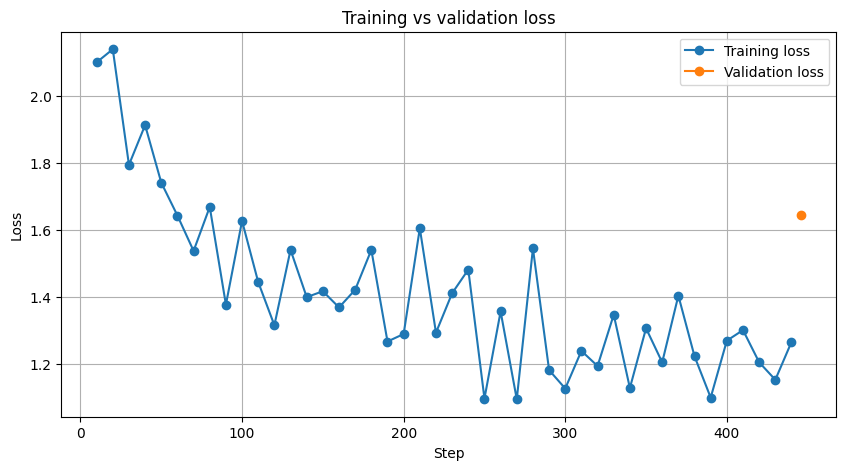

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
36,1.404606,4.960225,1.672432e-06,0.829596,370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,1.224016,5.610281,1.284583e-06,0.852018,380,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,1.100976,6.278799,9.447846e-07,0.874439,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,1.270547,6.152416,6.549118e-07,0.896861,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,1.301961,5.368021,4.165621e-07,0.919283,410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,1.206142,6.507068,2.310497e-07,0.941704,420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,1.154064,5.534794,9.939749e-08,0.964126,430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,1.266458,5.385886,2.233121e-08,0.986547,440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44,NaN,NaN,NaN,1.000000,446,1.644309,20.4223,9.793,4.897,NaN,NaN,NaN,NaN,NaN
45,NaN,NaN,NaN,1.000000,446,NaN,NaN,NaN,NaN,1150.003,3.103,0.388,8.918422e+15,1.410832


In [18]:
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)

plt.figure(figsize=(10, 5))
if "loss" in history.columns:
    train_rows = history.dropna(subset=["loss"])
    plt.plot(train_rows["step"], train_rows["loss"], marker="o", label="Training loss")
if "eval_loss" in history.columns:
    eval_rows = history.dropna(subset=["eval_loss"])
    plt.plot(eval_rows["step"], eval_rows["eval_loss"], marker="o", label="Validation loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs validation loss")
plt.legend()
plt.grid(True)
plt.show()

display(history.tail(10))

## 18. Final test evaluation: base model vs fine-tuned model

In [19]:
# Reload the untouched base model for the baseline test benchmark.
# The final test set has never been used for training or hard-example mining.
del model
gc.collect()
torch.cuda.empty_cache()

base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

model = base_model
tokenizer = base_tokenizer
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

terminators = [tokenizer.eos_token_id]
eot_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")
if eot_id is not None and eot_id != tokenizer.unk_token_id:
    terminators.append(eot_id)

base_test_preds = generate_dataset(model, test_ds, "Base test")

==((====))==  Unsloth 2026.7.5: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Base test: 0/300


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=

Base test: 100/300


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

Base test: 200/300


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

In [20]:
# The trainer retains the best checkpoint selected by validation loss.
model = trainer.model
tokenizer = trainer.processing_class

finetuned_test_preds = generate_dataset(model, test_ds, "Fine-tuned test")
references = test_ds["english"]

print("Generated base and fine-tuned predictions.")

Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Fine-tuned test: 0/300


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

Fine-tuned test: 100/300


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

Fine-tuned test: 200/300


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

Generated base and fine-tuned predictions.


## 19. Compute BLEU, chrF++, exact match, and optional BERTScore

In [21]:
def exact_match_rate(preds, refs):
    return 100.0 * np.mean([
        normalized_exact_match(p, r)
        for p, r in zip(preds, refs)
    ])

base_bleu = sacrebleu.corpus_bleu(base_test_preds, [references])
ft_bleu = sacrebleu.corpus_bleu(finetuned_test_preds, [references])

base_chrf = sacrebleu.corpus_chrf(base_test_preds, [references])
ft_chrf = sacrebleu.corpus_chrf(finetuned_test_preds, [references])

results = {
    "Base BLEU": base_bleu.score,
    "Fine-tuned BLEU": ft_bleu.score,
    "BLEU improvement": ft_bleu.score - base_bleu.score,
    "Base chrF++": base_chrf.score,
    "Fine-tuned chrF++": ft_chrf.score,
    "chrF++ improvement": ft_chrf.score - base_chrf.score,
    "Base exact match %": exact_match_rate(base_test_preds, references),
    "Fine-tuned exact match %": exact_match_rate(finetuned_test_preds, references),
}

if RUN_BERTSCORE:
    try:
        from bert_score import score as bert_score
        P_b, R_b, F_b = bert_score(
            base_test_preds, references,
            lang="en", verbose=True, batch_size=EVAL_BATCH_SIZE
        )
        P_f, R_f, F_f = bert_score(
            finetuned_test_preds, references,
            lang="en", verbose=True, batch_size=EVAL_BATCH_SIZE
        )
        results["Base BERTScore F1"] = float(F_b.mean())
        results["Fine-tuned BERTScore F1"] = float(F_f.mean())
        results["BERTScore improvement"] = float(F_f.mean() - F_b.mean())
    except Exception as e:
        print("BERTScore unavailable:", type(e).__name__, str(e)[:300])

display(pd.DataFrame([results]).T.rename(columns={0: "value"}))

,value
Base BLEU,8.561332
Fine-tuned BLEU,15.761998
BLEU improvement,7.200666
Base chrF++,35.450353
Fine-tuned chrF++,40.899231
chrF++ improvement,5.448878
Base exact match %,2.000000
Fine-tuned exact match %,3.333333


## 20. Category-wise evaluation

In [22]:
def evaluate_subset(indices, name):
    refs = [references[i] for i in indices]
    bp = [base_test_preds[i] for i in indices]
    fp = [finetuned_test_preds[i] for i in indices]

    b = sacrebleu.corpus_bleu(bp, [refs]).score
    f = sacrebleu.corpus_bleu(fp, [refs]).score
    cb = sacrebleu.corpus_chrf(bp, [refs]).score
    cf = sacrebleu.corpus_chrf(fp, [refs]).score

    return {
        "category": name,
        "n": len(indices),
        "base_BLEU": b,
        "fine_tuned_BLEU": f,
        "BLEU_delta": f - b,
        "base_chrF++": cb,
        "fine_tuned_chrF++": cf,
        "chrF++_delta": cf - cb,
    }

category_rows = []
categories = test_ds["category"]
lengths = test_ds["length_bucket"]

for cat in sorted(set(categories)):
    idx = [i for i, x in enumerate(categories) if x == cat]
    if len(idx) >= 10:
        category_rows.append(evaluate_subset(idx, cat))

for bucket in ["short", "medium", "long"]:
    idx = [i for i, x in enumerate(lengths) if x == bucket]
    if len(idx) >= 10:
        category_rows.append(evaluate_subset(idx, f"length_{bucket}"))

category_results = pd.DataFrame(category_rows)
display(category_results.sort_values("BLEU_delta", ascending=False))

,category,n,base_BLEU,fine_tuned_BLEU,BLEU_delta,base_chrF++,fine_tuned_chrF++,chrF++_delta
3,length_short,176,7.933359,18.734975,10.801616,32.223877,43.162180,10.938302
2,short,45,9.026912,17.896162,8.869251,32.290649,41.993285,9.702636
0,general,19,12.511565,20.057126,7.545561,34.715476,44.369873,9.654398
1,numeric_or_proper_noun,235,8.201891,15.124410,6.922519,35.715219,40.492089,4.776869
4,length_medium,106,8.868171,15.602235,6.734063,37.063134,42.923247,5.860113
5,length_long,18,8.970784,11.441314,2.470529,36.904416,33.604005,-3.300412


## 20b. Bonus check: in-distribution synthetic evaluation

This uses `synthetic_holdout_ds` — a slice of your `iwasbinod/nepali_translation_jsonl_format`
set that was **never used for training, hard-mining, or validation**. It shows how well the
fine-tuned model learned the specific patterns you generated (idioms, news-style phrasing,
number/date formatting, etc.), broken down by your original category labels. Treat the main
organic test set (section 18-20) as the primary "does it generalize" result, and this section
as a secondary "did it learn my patterns" result.


In [23]:
if len(synthetic_holdout_ds) > 0:
    print("Running bonus evaluation on the synthetic holdout (in-distribution check)...")

    base_synth_preds = generate_dataset(base_model, synthetic_holdout_ds, "Base (synthetic holdout)")

    ft_model = trainer.model
    ft_tokenizer = trainer.processing_class
    # generate_one/generate_dataset read the *global* `tokenizer`, so swap it in
    # temporarily for the fine-tuned pass and restore afterward.
    _prev_tokenizer = tokenizer
    tokenizer = ft_tokenizer
    ft_synth_preds = generate_dataset(ft_model, synthetic_holdout_ds, "Fine-tuned (synthetic holdout)")
    tokenizer = _prev_tokenizer

    synth_refs = synthetic_holdout_ds["english"]
    b = sacrebleu.corpus_bleu(base_synth_preds, [synth_refs]).score
    f = sacrebleu.corpus_bleu(ft_synth_preds, [synth_refs]).score
    cb = sacrebleu.corpus_chrf(base_synth_preds, [synth_refs]).score
    cf = sacrebleu.corpus_chrf(ft_synth_preds, [synth_refs]).score

    print(f"Synthetic holdout BLEU   -> base: {b:.2f}  fine-tuned: {f:.2f}  delta: {f - b:+.2f}")
    print(f"Synthetic holdout chrF++ -> base: {cb:.2f}  fine-tuned: {cf:.2f}  delta: {cf - cb:+.2f}")

    synth_category_results = pd.DataFrame()
    if "src_category" in synthetic_holdout_ds.column_names:
        synth_cat_rows = []
        src_cats = synthetic_holdout_ds["src_category"]
        for cat in sorted(set(src_cats)):
            idx_c = [i for i, x in enumerate(src_cats) if x == cat]
            if len(idx_c) >= 5:
                refs_c = [synth_refs[i] for i in idx_c]
                bp = [base_synth_preds[i] for i in idx_c]
                fp = [ft_synth_preds[i] for i in idx_c]
                synth_cat_rows.append({
                    "synthetic_category": cat,
                    "n": len(idx_c),
                    "base_BLEU": sacrebleu.corpus_bleu(bp, [refs_c]).score,
                    "fine_tuned_BLEU": sacrebleu.corpus_bleu(fp, [refs_c]).score,
                })
        synth_category_results = pd.DataFrame(synth_cat_rows)
        if len(synth_category_results):
            synth_category_results["BLEU_delta"] = (
                synth_category_results["fine_tuned_BLEU"] - synth_category_results["base_BLEU"]
            )
            display(synth_category_results.sort_values("BLEU_delta", ascending=False))

    synth_category_results.to_csv("synthetic_holdout_category_results.csv", index=False)
else:
    print("SYNTHETIC_HOLDOUT_SIZE is 0 or no synthetic data available; skipping bonus check.")


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running bonus evaluation on the synthetic holdout (in-distribution check)...
Base (synthetic holdout): 0/100


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=

Fine-tuned (synthetic holdout): 0/100


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

Synthetic holdout BLEU   -> base: 31.94  fine-tuned: 61.96  delta: +30.02
Synthetic holdout chrF++ -> base: 59.60  fine-tuned: 78.01  delta: +18.41


,synthetic_category,n,base_BLEU,fine_tuned_BLEU,BLEU_delta
3,Numbers/Dates/Proper Nouns,26,27.184703,81.269250,54.084548
4,Short/Simple,25,22.817260,60.771089,37.953829
2,News-domain,21,35.973573,73.297154,37.323581
5,Technical/Scientific,5,22.079669,53.502692,31.423023
0,Complex/Compound,13,14.042703,42.775423,28.732720
1,Long Paragraph,6,38.875292,57.341445,18.466153


## 21. Side-by-side qualitative analysis

In [24]:
comparison = pd.DataFrame({
    "nepali": test_ds["nepali"],
    "reference": references,
    "base_model": base_test_preds,
    "fine_tuned": finetuned_test_preds,
})

comparison["base_f1"] = [
    word_f1(p, r) for p, r in zip(comparison["base_model"], comparison["reference"])
]
comparison["fine_tuned_f1"] = [
    word_f1(p, r) for p, r in zip(comparison["fine_tuned"], comparison["reference"])
]
comparison["delta"] = comparison["fine_tuned_f1"] - comparison["base_f1"]

display(comparison.sort_values("delta", ascending=False).head(15))

,nepali,reference,base_model,fine_tuned,base_f1,fine_tuned_f1,delta
239,रङ स्तम्भ,Color Column,"The Nepali text ""रङ स्तम्भ"" translates to ""Ran...",Color column,0.000000,1.000000,1.000000
241,यूआरएल प्राप्त गरियो,Received URL,You will get it.,URL received,0.000000,1.000000,1.000000
105,महिना दृश्य,Month View,Mahina Drishti,Month view,0.000000,1.000000,1.000000
87,उनीहरूले तपाईँको पुर्खाको भाषा कुन हो ?,What is your father's native language?,Who speaks the language of the gods?,What is your father's language?,0.000000,0.909091,0.909091
185,नजिकै फिल्म हल थियो ।,There was a movie nearby.,The film is called The Thief.,There was a movie near.,0.000000,0.800000,0.800000
136,कफी पिउनुका धेरै फाइदाहरु छन् ।,There are many benefits to drink coffee.,Coffee is very beneficial.,There are many benefits of drinking coffee.,0.000000,0.714286,0.714286
198,मैले युट्युबमा उनकी छोरीको पनि भिडियो देखेको ब...,I have seen also your video on youtube.,They watched videos on YouTube about her.,I have also seen their daughter's video on You...,0.133333,0.823529,0.690196
191,यि सेटिङहरू संग बिटम्याप निर्यात गर्नुहोस्,Export the bitmap file with these settings,Setiing haru sang bitmaap niryat garnehuos.,Export the settings to BitMap,0.000000,0.666667,0.666667
131,"बिक्री राम्रै छ,' उनले भनिन्।","Sales are going well, he said.","Bikri Ramrai che, unle bhanin.","""Sales are going well,"" he said.",0.000000,0.666667,0.666667
0,यसका सदस्यहरू को-को हुन् ?,Who are the members of it?,Are you a member?,Who are the members of this?,0.200000,0.833333,0.633333


## 22. Regression analysis: find cases where fine-tuning became worse

In [25]:
regressions = comparison.sort_values("delta", ascending=True).head(15)
display(regressions)

print("Regression count:",
      int((comparison["delta"] < -0.05).sum()),
      "of", len(comparison))

print(
    "A strong model should improve aggregate metrics while keeping regressions "
    "low. If many regressions appear, inspect those examples and add targeted "
    "counterexamples in the next training iteration."
)

,nepali,reference,base_model,fine_tuned,base_f1,fine_tuned_f1,delta
63,समूह आधार:,Group base:,Group,Group:,0.666667,0.000000,-0.666667
15,"लाग्छ, कुनै उद्देश्य छैन मेरो",It seems I have no purpose.,I have no purpose.,There is no purpose for me,0.800000,0.166667,-0.633333
20,सामान्य मानिसहरुलाई पनि यसले असर गर्छ।,Common people too are affected by this.,Common people are also affected.,It also affects ordinary people.,0.500000,0.000000,-0.500000
52,सन् मा उनले विश्वको सबैभन्दा सुन्दर महिलाको शी...,"In 1994, she got the title of the most beautif...",She was considered the most beautiful woman in...,He was named the world's most beautiful woman.,0.666667,0.272727,-0.393939
210,मेरो सुगर अझै पनि सामान्य भएन ।,My head is not normal yet.,My sugar is not very common.,My sugar levels are still normal.,0.500000,0.166667,-0.333333
32,खरिदमा फाइनान्सिङको प्रक्रिया पनि सरल पारिएको छ।,The cash purchase process is also streamlined.,The financial process is also simplified.,The process of financing has also been simplif...,0.615385,0.333333,-0.282051
153,उठेका केही विषय वस्तुलाई सम्बोधन पनि गरिएको छ ।,Some advanced topics are also covered.,Some topics of discussion are also being discu...,Some of the topics have been discussed.,0.571429,0.307692,-0.263736
200,उनको व्यवसायिक जीवन कलेज शिक्षक र पत्रकारको रु...,He then embarked on his professional life as a...,He started his business life as a college teac...,His business life began as a teacher and journ...,0.750000,0.500000,-0.250000
67,त्यसमा केही विलम्ब भएको छ ।,It has some delay.,There is some delay.,There is a delay.,0.500000,0.250000,-0.250000
283,मुखिनी बज्यै नाम यति चिने जानेको नाउँ भयो कि म...,Mukni Bajayya is known as a very known name th...,"My mother-in-law's name is known as Chinai, an...",I have not yet found out the name of my mother...,0.478261,0.228571,-0.249689


Regression count: 48 of 300
A strong model should improve aggregate metrics while keeping regressions low. If many regressions appear, inspect those examples and add targeted counterexamples in the next training iteration.


## 23. Save the adapter locally

In [26]:
adapter_path = ADAPTER_NAME

model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

comparison.to_csv("translation_test_comparison.csv", index=False)
category_results.to_csv("category_results.csv", index=False)
pd.DataFrame([results]).to_csv("overall_results.csv", index=False)

print("Saved adapter and evaluation artifacts.")

Unsloth: Restored added_tokens_decoder metadata in llama-3.2-3b-nepali-english-translation-with_syn_v4/tokenizer_config.json.


Saved adapter and evaluation artifacts.


## 24. Push adapter to Hugging Face

In [27]:
repo_id = f"{HF_USERNAME}/{ADAPTER_NAME}"

model.push_to_hub(repo_id, token=hf_token)
tokenizer.push_to_hub(repo_id, token=hf_token)

print("Adapter uploaded to:", repo_id)

README.md:   0%|          | 0.00/567 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/iwasbinod/llama-3.2-3b-nepali-english-translation-with_syn_v4


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpw55m3d0s/tokenizer_config.json.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


Adapter uploaded to: iwasbinod/llama-3.2-3b-nepali-english-translation-with_syn_v4


## 25. Final interpretation checklist

### A successful run should ideally show:
- Fine-tuned BLEU > Base BLEU.
- Fine-tuned chrF++ > Base chrF++.
- Fine-tuned semantic score > Base semantic score, when BERTScore is available.
- Improvement across multiple category buckets, not only one.
- Validation loss decreases without a large train/validation divergence.
- The number of regressions is small and understandable.
- Qualitative examples show better tense, meaning preservation, names, numbers, and long-sentence handling.

### Before a full Kaggle run
1. Set `QUICK_RUN = True`.
2. Run the notebook from the beginning and verify the data pipeline, collator, trainer, checkpoint restore, generation, and evaluation all complete.
3. Set `QUICK_RUN = False` for the full experiment.
4. If GPU time is tight, set `RUN_BERTSCORE = False` during the first full run; BERTScore is optional and can be run later on saved predictions.

### If the fine-tuned model is not better
Do not immediately increase epochs or LoRA rank.

First inspect:
1. Are the references actually high quality?
2. Is the training set dominated by noisy or repetitive examples?
3. Is the model learning the translation target or merely formatting?
4. Are hard examples genuinely difficult, or simply bad references?
5. Is the final test distribution different from the training distribution?
6. Are there too many regressions in a particular category?

The next iteration should be driven by failure analysis rather than blind hyperparameter changes.